# 🎓 Da IA Discriminativa à Generativa: Redes Neurais Adversariais Generativas (GANs)
**Disciplina:** GENERATIVE AI & ADVANCED NETS  
**Curso:** Tecnólogo em Inteligência Artificial  

---

## 🎯 Objetivos de Aprendizagem

Ao final desta aula prática, você será capaz de:
1. **Compreender** a transição do paradigma da IA Discriminativa ($P(Y|X)$) para a IA Generativa ($P(X)$).
2. **Explicar** a arquitetura e a dinâmica do jogo Minimax de soma zero entre o **Gerador ($G$)** e o **Discriminador ($D$)**.
3. **Construir e treinar** uma **DCGAN (Deep Convolutional GAN)** completa no Keras com o dataset *Fashion-MNIST*.
4. **Implementar** um loop de treinamento customizado com `tf.GradientTape` controlando perdas separadas para ambos os modelos.
5. **Identificar** os principais gargalos e instabilidades de treinamento: *Mode Collapse*, desbalanço de gradientes e o Ponto de Equilíbrio de Nash.
6. **Visualizar** a evolução da capacidade do Gerador em transformar ruído gaussiano em imagens sintéticas de alta fidelidade.
7. **Reconhecer** as aplicações industriais e as limitações das GANs no mercado atual.

## 1. Generative Adversarial Networks - GANs

As **GANs** revolucionaram a geração sintética ao propor uma competição entre duas redes neurais treinadas simultaneamente em um **Jogo de Soma Zero (Minimax Game)**:

$$
\min_G \max_D V(D,G) = \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]
$$

* **Gerador ($G$):** Recebe um vetor de ruído estocástico $z \sim p_z$ e tenta mapeá-lo para uma imagem sintética $G(z)$ realista o suficiente para enganar $D$.
* **Discriminador ($D$):** Atua como um classificador binário que avalia uma imagem e estima a probabilidade de ela ser real ($x \sim p_{\text{data}}$) ou falsa ($G(z)$).

Simplificando:
$$
\frac{1}{m}\sum_{i=1}^{m}\log D(x_i)
+
\frac{1}{m}\sum_{i=1}^{m}\log\left(1-D(G(z_i))\right)
$$



- $m$: tamanho do mini-batch utilizado no treinamento.
- $D(x_i)$: probabilidade atribuída pelo discriminador de que a amostra $(x_i)$ seja real.
- $D(G(z_i))$: probabilidade atribuída pelo discriminador de que a amostra gerada $(G(z_i))$ seja real.


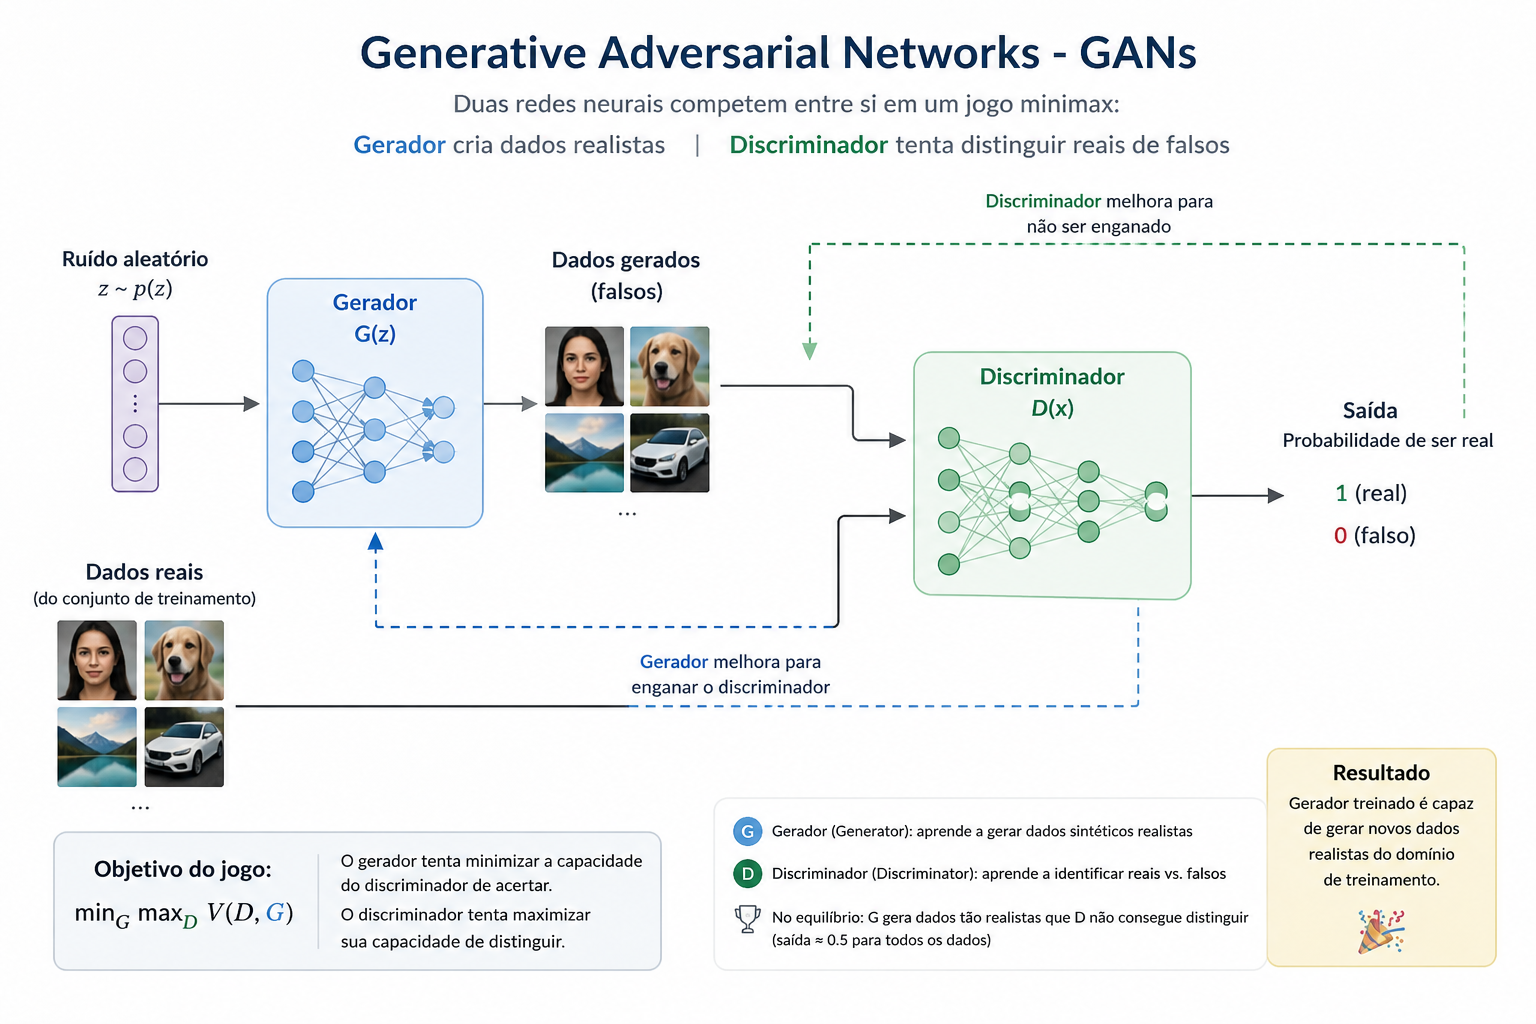

**As principais aplicações práticas das GANs no mercado atual são:**
1. Super-Resolução e Upscaling em Tempo Real (Games e Vídeo)
  - Como funciona: Modelos como ESRGAN e Real-ESRGAN aumentam a resolução de imagens de baixa qualidade sem deixá-las borradas, pois o Discriminador força o Gerador a inventar texturas nítidas e realistas (pele, cabelo, tecido).
    - Casos de Uso:
      - Gaming (NVIDIA DLSS e Upscaling): Redução do esforço da placa de vídeo ao renderizar o jogo em 1080p e usar uma GAN/rede neural para elevar em tempo real para 4K a 60+ FPS.
      - Remasterização de Mídia: Restauração automatizada de filmes antigos, acervos históricos e vídeos para plataformas de streaming (Netflix, YouTube).
2. Geração de Dados Sintéticos e Aumento de Dados (Data Augmentation)
  - Como funciona: Em setores onde dados reais são escassos, caros ou protegidos por leis de privacidade, GANs são usadas para criar datasets sintéticos que mantêm as propriedades estatísticas dos dados reais.  
    - Casos de Uso:
      - Finanças (Detecção de Fraude): Como transações fraudulentas representam menos de 0,01% dos dados, GANs geram transações sintéticas de fraude para treinar classificadores sem desbalanceamento.  
      - Saúde e Imagens Médicas: Geração de exames sintéticos (raios-X, ressonâncias) de doenças raras para treinar IAs médicas sem violar a privacidade dos pacientes (LGPD / HIPAA).
      - Veículos Autônomos: Empresas como Waymo usam GANs para gerar cenários raros ou perigosos de trânsito (ex: tempestades de neve intensas, pedestres atravessando fora da faixa) para treinar a visão computacional dos carros.  
3. Avatares Virtuais, Dublagem e Deepfakes em Tempo Real
  - Como funciona: A capacidade de gerar imagens e vídeo frame a frame em milissegundos torna as GANs a arquitetura padrão para síntese facial ao vivo.
    - Casos de Uso:  
      - Sincronização Labial e Dublagem Automática: Ajustar o movimento da boca de atores para coincidir com o áudio dublado em diferentes idiomas no cinema e em cursos online.
      - Avatares Interativos: Criação de atendentes virtuais em tempo real em videochamadas para suporte ao cliente.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU

#### 2. Criando uma distribuição de dados reais

In [ ]:
# ============================================================
# ETAPA 1.1 — Criando uma distribuição de dados reais
# ============================================================

# Reprodutibilidade
import os
import random

SEED = 200

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

tf.keras.utils.set_random_seed(SEED)

# TensorFlow determinístico
tf.config.experimental.enable_op_determinism()

print(f"TensorFlow: {tf.__version__}")

# ------------------------------------------------------------
# Distribuição real:
# dois grupos de pontos formando uma distribuição simples
# ------------------------------------------------------------

n_real = 2000

cluster_1 = np.random.normal(
    loc=[-2, 0],
    scale=0.6,
    size=(n_real // 2, 2)
)

cluster_2 = np.random.normal(
    loc=[2, 0],
    scale=0.6,
    size=(n_real // 2, 2)
)

real_data = np.vstack([cluster_1, cluster_2])

plt.figure(figsize=(7, 4))
plt.scatter(
    real_data[:, 0],
    real_data[:, 1],
    alpha=0.5,
    s=12
)

plt.title("Distribuição dos dados reais")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(alpha=0.2)
plt.show()

#### 3. Construindo o Generator

In [ ]:
latent_dim = 2

# TODO Crie uma rede Sequential com Input com shape=(latent_dim,)
# duas camadas Dense com 16 neurônios e activation='relu' e
# uma camada Dense final com 2 neurônios

G = ...

G.summary()

#### 4. Testando o Generator antes do treinamento

In [ ]:
# Gera 500 vetores aleatórios no espaço latente
z = tf.random.normal(shape=(500, latent_dim))

In [ ]:
# TODO Use o Gerador G para gerar dados com z e training = False
# Depois converta para numpy
fake_samples = ...
fake_samples

In [ ]:
plt.figure(figsize=(7, 4))
plt.scatter(
    fake_samples[:, 0],
    fake_samples[:, 1],
    alpha=0.5,
    s=12
)

plt.title("Saída inicial do Generator")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.grid(alpha=0.2)
plt.show()

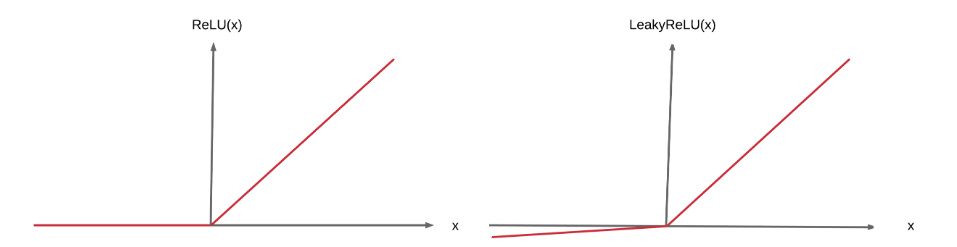

Diferentemente da ReLU, a LeakyReLU não zera completamente valores negativos, ajudando a manter o fluxo de gradientes durante o treinamento e tornando o Discriminator mais estável do que usando apenas ReLU.

#### 5. Construindo o Discriminator

In [ ]:
# TODO Crie uma rede Sequential com Input com shape=(2,)
# duas camadas Dense com 16 neurônios seguidas de LeakyReLU
# e uma camada Dense final com 1 neurônio e activation='sigmoid'

D = ...

D.summary()

In [ ]:
# O Discriminator recebe uma amostra e retorna
# uma probabilidade entre 0 e 1.

sample = tf.convert_to_tensor(
    real_data[:5],
    dtype=tf.float32
)

probability = D(sample, training=False)

print("Probabilidades iniciais:")
print(tf.squeeze(probability).numpy())

#### 6. Loss e Otimizadores

In [ ]:
# Binary Crossentropy:
# mede o erro em problemas de classificação binária.
# Aqui o Discriminator precisa distinguir REAL (1) de FAKE (0).
# TODO Atribua a loss_fn tf.keras.losses.BinaryCrossentropy()
loss_fn = ...


# Adam utiliza médias móveis dos gradientes.
# beta_1 controla o quanto o histórico recente influencia as atualizações.
# Em GANs é comum usar beta_1=0.5 para reduzir a influência
# de gradientes antigos e tornar o treinamento mais estável.

# TODO crie o optimizer_D como tf.keras.optimizers.Adam
# com learning_rate=0.002 e beta_1=0.5
optimizer_D = ...

# TODO crie o optimizer_G como tf.keras.optimizers.Adam
# com learning_rate=0.002 e beta_1=0.5
optimizer_G = ...

print("Loss:", loss_fn)
print("Optimizer D:", optimizer_D)
print("Optimizer G:", optimizer_G)

#### 7. Treinamento da GAN

In [ ]:
batch_size = 128
epochs = 200

G_losses = []
D_losses = []

for epoch in range(epochs):

    # --------------------------------------------------------
    # Minibatch de dados reais
    # --------------------------------------------------------

    idx = np.random.randint(
        0,
        len(real_data),
        batch_size
    )

    real_batch = real_data[idx].astype(np.float32)

    real_labels = tf.ones((batch_size, 1))
    fake_labels = tf.zeros((batch_size, 1))

    # ========================================================
    # 1. TREINAR DISCRIMINATOR
    # ========================================================

    z = tf.random.normal(
        shape=(batch_size, latent_dim)
    )

    with tf.GradientTape() as tape:

        # TODO Chame o gerador G com training=True para gerar uma fake batch
        # a partir de z
        fake_batch = ...

        # TODO Chame o Discriminator D para identificar os dados reais a
        # partir de real_batch
        output_real = ...

        # TODO Chame o Discriminator D para identificar os dados falsos a
        # partir de fake_batch
        output_fake = ...

        # TODO Calcule a loss dos dados reais chamanda a loss_fn dando como
        # input real_labels e output_real
        loss_real = ...

        # TODO Calcule a loss dos dados falsos chamanda a loss_fn dando como
        # input fake_labels e output_fake
        loss_fake = ...

        # TODO Calcule a loss do discriminator somando loss_real e loss_fake
        loss_D = ...

    gradients_D = tape.gradient(
        loss_D,
        D.trainable_variables
    )

    optimizer_D.apply_gradients(
        zip(
            gradients_D,
            D.trainable_variables
        )
    )

    # ========================================================
    # 2. TREINAR GENERATOR
    # ========================================================

    z = tf.random.normal(
        shape=(batch_size, latent_dim)
    )

    with tf.GradientTape() as tape:

        # TODO Chame o gerador G com training=True para gerar uma fake batch
        # a partir de z
        fake_batch = ...

        # TODO Chame o Discriminator D para identificar os dados falsos a
        # partir de fake_batch
        output = ...

        # TODO Calcule a loss dos dados falsos chamanda a loss_fn dando como
        # input real_labels e output
        loss_G = ...

    gradients_G = tape.gradient(
        loss_G,
        G.trainable_variables
    )

    optimizer_G.apply_gradients(
        zip(
            gradients_G,
            G.trainable_variables
        )
    )

    # --------------------------------------------------------
    # Histórico
    # --------------------------------------------------------

    G_losses.append(loss_G.numpy())
    D_losses.append(loss_D.numpy())

    # --------------------------------------------------------
    # Progresso
    # --------------------------------------------------------

    if epoch == 1 or epoch % 25 == 0:

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"Loss D: {loss_D:.3f} | "
            f"Loss G: {loss_G:.3f}"
        )

#### 8. O que o Generator aprendeu?

In [ ]:
# ============================================================
# ETAPA 2.1 — O que o Generator aprendeu?
# ============================================================

z = tf.random.normal(
    shape=(1000, latent_dim)
)

generated = G(
    z,
    training=False
).numpy()

plt.figure(figsize=(8, 5))

plt.scatter(
    real_data[:, 0],
    real_data[:, 1],
    alpha=0.15,
    s=10,
    label="Dados reais"
)

plt.scatter(
    generated[:, 0],
    generated[:, 1],
    alpha=0.5,
    s=10,
    label="Gerados pela GAN"
)

plt.title("GAN após o treinamento")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

#### 9. Evolução das perdas

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    G_losses,
    label="Generator Loss"
)

plt.plot(
    D_losses,
    label="Discriminator Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Dinâmica adversarial durante o treinamento")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Dinâmica adversarial durante o treinamento

O gráfico mostra a evolução das funções de perda (*loss*) do **Gerador** e do **Discriminador** ao longo das épocas de treinamento. Diferentemente de modelos supervisionados tradicionais, em GANs não se espera uma redução monotônica das perdas, pois ambas as redes competem continuamente em um jogo de soma não zero.

Observa-se que as curvas oscilam durante o treinamento, refletindo a dinâmica adversarial entre os modelos. Após as primeiras épocas, as perdas tendem a se estabilizar em faixas relativamente constantes, indicando que o Gerador está produzindo amostras cada vez mais realistas enquanto o Discriminador encontra maior dificuldade em distingui-las das amostras reais. Esse comportamento sugere que a GAN atingiu um equilíbrio aproximado entre os dois agentes.

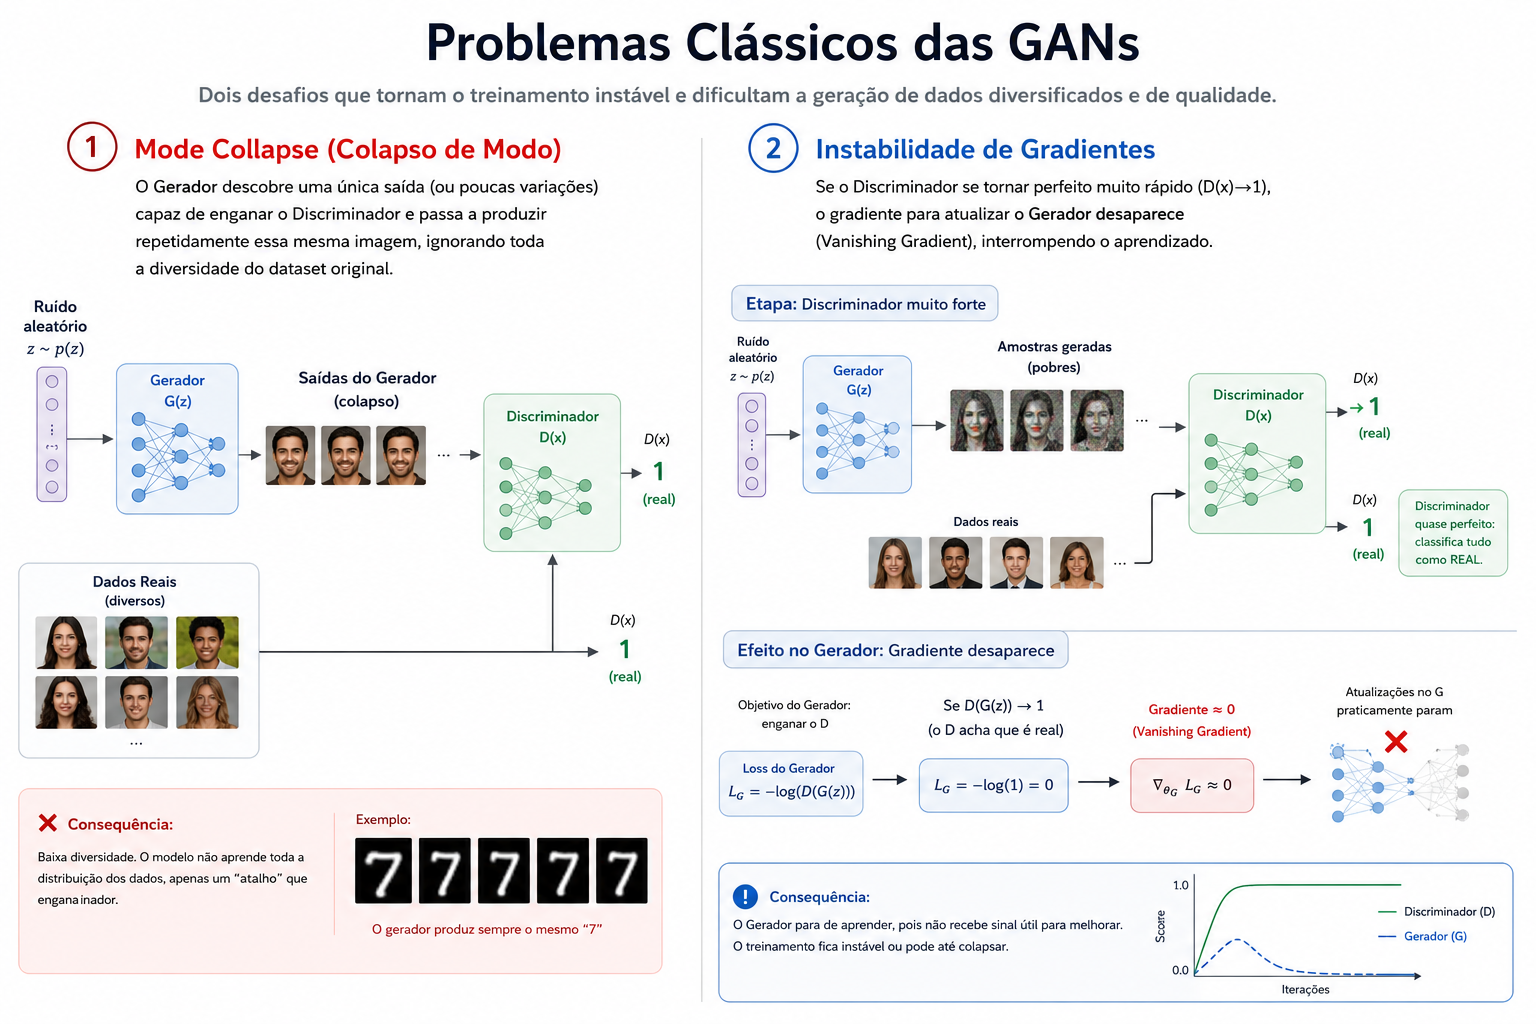

# 10. Conclusão

Nesta aula, exploramos a transição para a IA Generativa e o funcionamento das Redes Adversariais:

* **GAN (DCGAN) — Paradigma Generativo:** Introduz a criação de dados sintéticos a partir de vetores de ruído aleatório ($z$) por meio do jogo minimax entre o Gerador e o Discriminador.
* **Vantagens e Desafios:** A arquitetura se destaca por ser **ultra-rápida** na geração (requer apenas uma passada pela rede), porém apresenta desafios severos de treinamento, como **instabilidade de gradientes** e **mode collapse** (quando o gerador vicia em poucas variantes de saída).

Com o domínio das GANs e VAEs, entendemos a base da criação de mídias sintéticas, preparando o terreno para arquiteturas baseadas em processos estatísticos de difusão.